# Kamrul Haq Mansoori

Data Science intern Oasis infobyte internship

Problem statement : Unemployment analysis with Python

Unemployment is measured by the unemployment rate which is the number of people who are unemployed as a percentage of the total labour force.We have seen a sharp increase in the unemployment rate during Covid-19,so analyzing the unemployment rate can be a good data science project. 

# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Unemployment Dataset(CSV)

In [4]:
df = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

# View Dataset

In [5]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [6]:
df.tail()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
262,West Bengal,30-06-2020,M,7.29,30726310,40.39,East,22.9868,87.855
263,West Bengal,31-07-2020,M,6.83,35372506,46.17,East,22.9868,87.855
264,West Bengal,31-08-2020,M,14.87,33298644,47.48,East,22.9868,87.855
265,West Bengal,30-09-2020,M,9.35,35707239,47.73,East,22.9868,87.855
266,West Bengal,31-10-2020,M,9.98,33962549,45.63,East,22.9868,87.855


# Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


In [8]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,12.236929,1.396211e+07,41.681573,22.826048,80.532425
std,10.803283,1.336632e+07,7.845419,6.270731,5.831738
min,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,75.850000,5.943376e+07,69.690000,33.778200,92.937600


# Check Missing Values

In [9]:
df.isnull().sum()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64

# Data Analysis

In [10]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')

In [11]:
# strip leading and trailing spaces from all column names
df.columns = df.columns.str.strip()

# Verify the fix - you should see no extra spaces now
print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


In [12]:
# Average Unemployment Rate by Region(state)
avg_unemployment = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)
print(avg_unemployment)

# Total Employment by Area (Region.1 corresponds to North,south,etc.)
region_employment = df.groupby('Region.1')['Estimated Employed'].sum()
print(region_employment)

Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Goa                 12.167000
Punjab              11.981000
Uttarakhand         11.156000
West Bengal         10.192000
Sikkim               9.792500
Uttar Pradesh        9.737000
Kerala               9.434000
Andhra Pradesh       8.664000
Maharashtra          7.979000
Chhattisgarh         7.819000
Karnataka            7.668000
Madhya Pradesh       6.854000
Telangana            6.833000
Odisha               6.462000
Gujarat              6.376000
Assam                4.856000
Meghalaya            3.866000
Name: Estimated Unemployment Rate (%), dtype: float64
Region.1
East          784094676
North        1032726546
Northeast     137450010
South         842435360
West          931175636


# Visualizing the Data

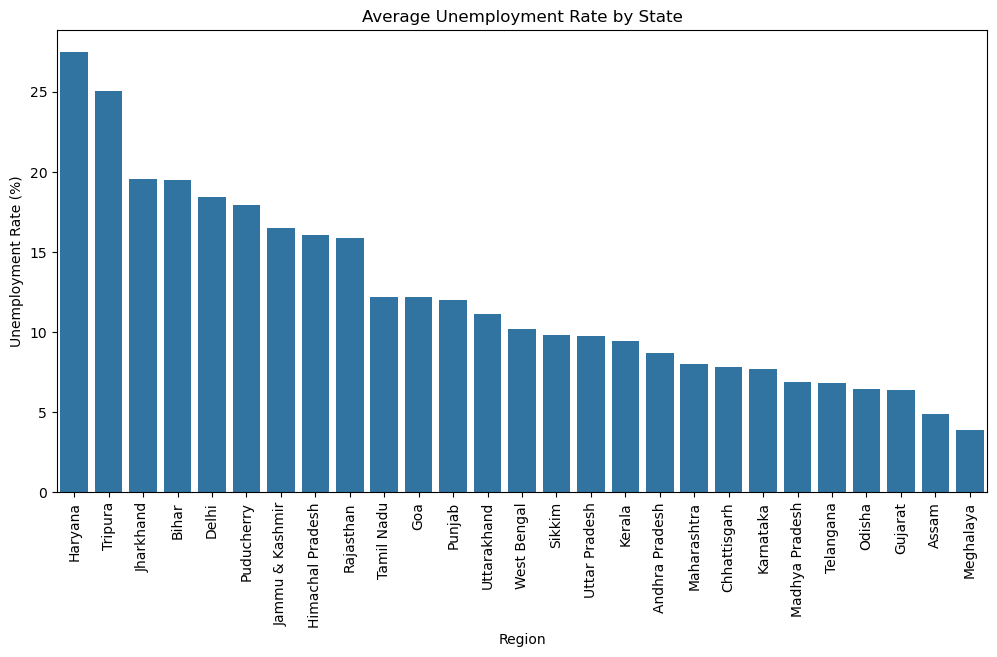

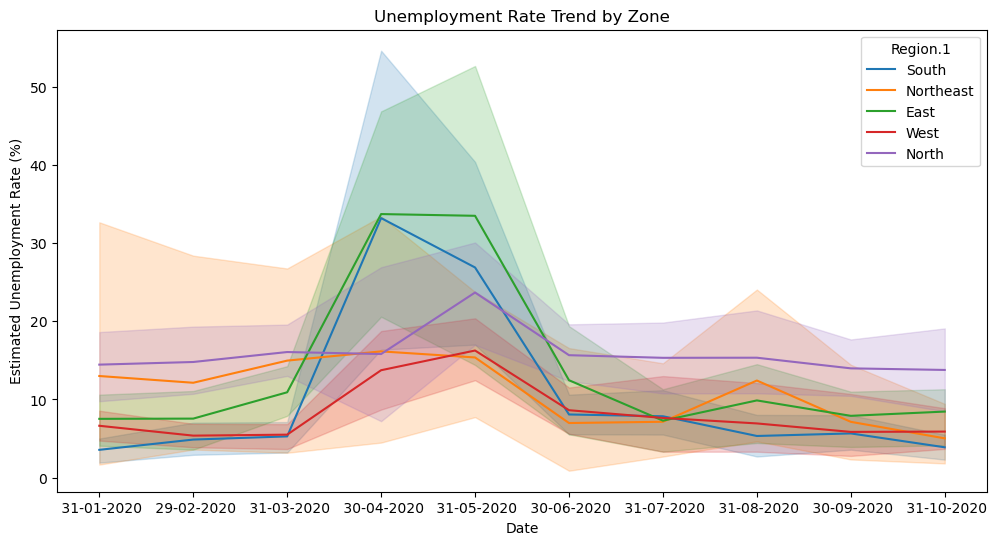

In [16]:
# Plotting Average Unemployment Rate by State
plt.figure(figsize=(12,6))
sns.barplot(x=avg_unemployment.index,y=avg_unemployment.values)
plt.xticks(rotation=90)
plt.title('Average Unemployment Rate by State')
plt.ylabel('Unemployment Rate (%)')
plt.show()

# Time series plot of unemployment rate over months
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)', hue='Region.1')
plt.title('Unemployment Rate Trend by Zone')
plt.show()

# Correlation Analysis

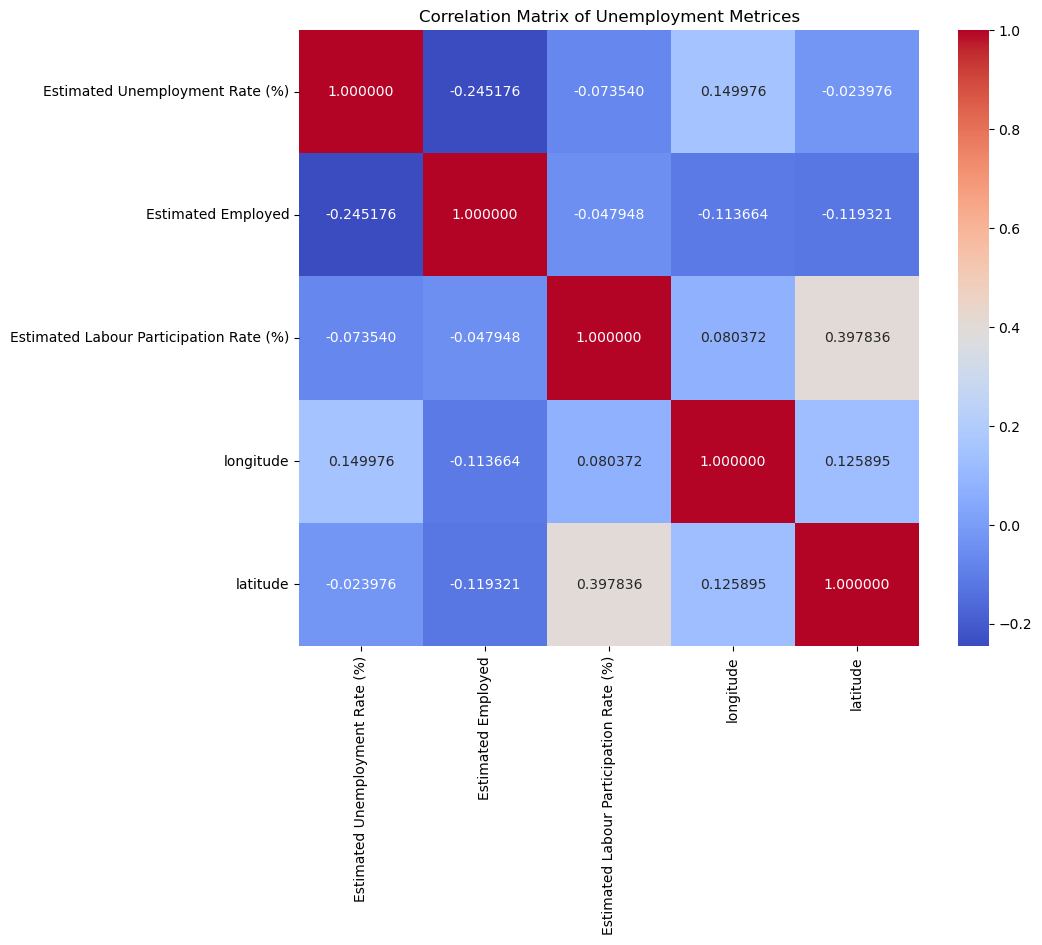

In [17]:
# Correlation Heatmap with numeric_only=True
plt.figure(figsize=(10,8))

# Only calculate correlation for numeric columns
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt="2f")

plt.title('Correlation Matrix of Unemployment Metrices')
plt.show()

# Comparing Employment vs.Unemplyoment

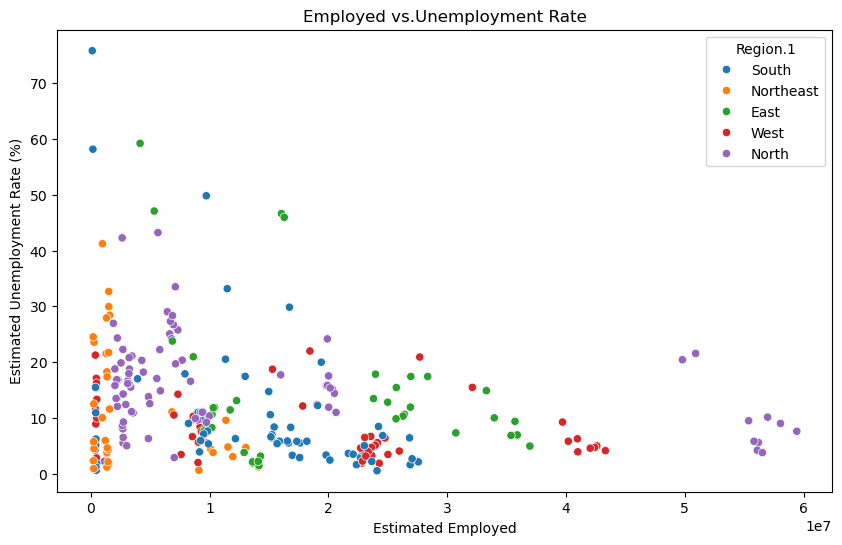

In [18]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Estimated Employed', y='Estimated Unemployment Rate (%)', hue='Region.1')
plt.title('Employed vs.Unemployment Rate')
plt.show()

# Distributon Visualization

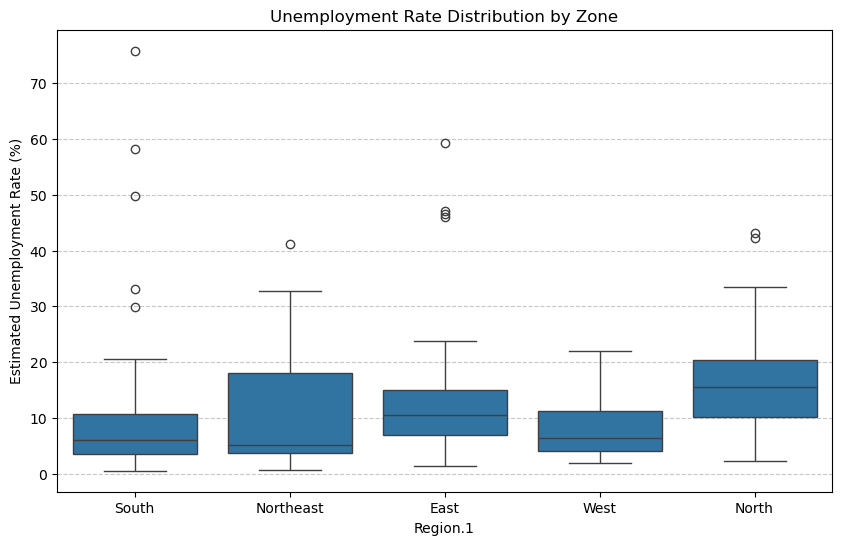

In [20]:
import seaborn as sns 
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(x='Region.1', y='Estimated Unemployment Rate (%)',data=df)
plt.title('Unemployment Rate Distribution by Zone')
plt.grid(axis='y',linestyle='--', alpha=0.7)
plt.show()

# Thank You